In [1]:
# If any import below fails, uncomment the line below, run it, then Restart Runtime:
# !pip install -q scikit-learn tensorflow opencv-python-headless

# ============================================================
# 🔧 Environment & Setup Check
# Run this first. It confirms every library works before we
# start building, and tells you if a GPU is available.
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Python version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

import sklearn
print("scikit-learn version:", sklearn.__version__)

import tensorflow as tf
print("TensorFlow version:", tf.__version__)

import cv2
print("OpenCV version:", cv2.__version__)

gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    print(f"\n✅ GPU available: {gpu_devices[0].name} — Project 2 will run faster.")
else:
    print("\nℹ️ No GPU detected — everything will still run, just a bit slower on Project 2.")
    print("   In Colab: Runtime → Change runtime type → Hardware accelerator → GPU")

print("\nAll core libraries imported successfully. You're ready to go! 🚀")

Python version: 3.11.0
NumPy version: 2.4.6
Pandas version: 3.0.5
scikit-learn version: 1.9.0
TensorFlow version: 2.21.0
OpenCV version: 5.0.0

ℹ️ No GPU detected — everything will still run, just a bit slower on Project 2.
   In Colab: Runtime → Change runtime type → Hardware accelerator → GPU

All core libraries imported successfully. You're ready to go! 🚀


# Project 1 — Sentiment Analysis 😊

## The Problem We Are Solving
Can a computer read a sentence and correctly decide whether it expresses a **positive** or **negative** opinion — without a human explicitly telling it what every word means?

This is a task from **Natural Language Processing (NLP)** — the branch of AI dealing with human language.

## Why This Isn't as Simple as It Sounds
A computer works with numbers, not words. It has no built-in understanding of what "loved" or "hated" means. So before any prediction can happen, we must convert text into numbers in a way that preserves useful information about the words used. Only after that conversion can a machine learning model be trained on it.

**Workflow for this project:**

`Raw Text → Convert to Numbers (TF-IDF) → Train a Model → Model Makes a Prediction`

We will build this step by step, so every stage stays visible and understandable.

## ✅ Prerequisites for Project 1

To follow this section comfortably, you should already know:
- **Python basics** — how to write a list, a function, and a `for` loop.
- **Pandas basics** — how to create a DataFrame (a table-like structure, similar to a spreadsheet, used to store and organize data in Python) and view it using `.head()`.
- **What classification means** — in Machine Learning, classification means teaching a model to assign an input to one of a fixed set of categories. Here, our two categories are "Positive" and "Negative." Because we are giving the model examples that are already labeled with the correct answer, this is called **supervised learning**.
- **(Helpful, not required) What a vector is** — simply an ordered list of numbers, such as `[0, 1, 0, 3]`. Understanding this makes the upcoming TF-IDF section much easier to follow.

If any of these feel shaky, a short refresher before class pays off.

## Step 1.1: Create the Dataset

Since this is a teaching example, we create a dataset by hand instead of downloading one, so the focus stays on understanding the process rather than on data collection.

**Why this dataset is larger than a handful of examples:** a model that only sees a few sentences per class does not have enough examples of each sentiment word to learn from — it may never encounter common words like "boring" or "excellent" often enough to know which class they belong to, and it will guess incorrectly on anything slightly different from what it saw. The dataset below uses 232 reviews (116 positive, 116 negative) built from a shared pool of common sentiment words ("amazing," "boring," "excellent," "disappointing," and so on) combined into many different sentence structures. This gives the model enough repeated examples of each word to learn a reliable pattern, while still varying the sentence structure enough that it has to learn actual word meaning rather than memorizing exact sentences.

What the code below does:
- Creates a Python list called `positive_reviews` and another called `negative_reviews`, containing realistic movie-review sentences.
- Combines them into a single list called `reviews`, and builds a matching `labels` list — `1` for every positive review, `0` for every negative review.
- Combines both into a single Pandas DataFrame called `sentiment_df` — a table with two columns, `review` and `sentiment`. Storing the data this way makes it far easier to filter, split, and process in the steps ahead.

This cell only displays the first few rows (`.head()`) instead of the full table, since the dataset is now much larger than before.

In [2]:
positive_reviews = [
    "Everyone agreed the ending was excellent",
    "I found the script to be wonderful",
    "The show turned out to be surprisingly brilliant",
    "I really loved how wonderful the performance was",
    "Everyone agreed the movie was fantastic",
    "I really loved how fantastic the direction was",
    "Everyone agreed this film was lovely",
    "I found the movie to be beautiful",
    "The acting was fun",
    "Everyone agreed the performance was beautiful",
    "The movie was impressive",
    "What a excellent show",
    "I found the direction to be excellent",
    "The performance was truly superb from start to finish",
    "I really loved how beautiful this film was",
    "I found the ending to be brilliant",
    "Everyone agreed the screenplay was refreshing",
    "The ending was engaging and kept me hooked",
    "I really loved how superb the ending was",
    "I really loved how stunning the story was",
    "What a beautiful film",
    "The show turned out to be surprisingly great",
    "What a engaging series",
    "I found the performance to be fantastic",
    "The show was truly heartwarming from start to finish",
    "The ending was excellent and kept me hooked",
    "I found the direction to be wonderful",
    "The show turned out to be surprisingly beautiful",
    "The ending turned out to be surprisingly stunning",
    "The performance was great and kept me hooked",
    "What a fantastic film",
    "I found the screenplay to be stunning",
    "What a solid movie",
    "The script was beautiful and kept me hooked",
    "Everyone agreed the plot was stunning",
    "The script was captivating",
    "The screenplay was truly captivating from start to finish",
    "The performance was brilliant and kept me hooked",
    "What a delightful movie",
    "I really loved how solid the story was",
    "The direction was remarkable and kept me hooked",
    "This film was outstanding and kept me hooked",
    "What a lovely direction",
    "What a heartwarming story",
    "This series turned out to be surprisingly heartwarming",
    "I really loved how remarkable the script was",
    "The story was truly fantastic from start to finish",
    "I really loved how impressive the story was",
    "The movie was truly great from start to finish",
    "The plot was superb",
    "The story turned out to be surprisingly heartwarming",
    "The performance turned out to be surprisingly beautiful",
    "The story was stunning",
    "Everyone agreed the screenplay was flawless",
    "Everyone agreed the direction was remarkable",
    "Everyone agreed this film was great",
    "I found the movie to be delightful",
    "The acting was truly engaging from start to finish",
    "This film was charming",
    "This film was truly amazing from start to finish",
    "I found the performance to be amazing",
    "Everyone agreed the acting was satisfying",
    "What a fun story",
    "The ending turned out to be surprisingly satisfying",
    "I found the screenplay to be brilliant",
    "The screenplay was engaging and kept me hooked",
    "I found the screenplay to be superb",
    "The story turned out to be surprisingly brilliant",
    "This series was enjoyable and kept me hooked",
    "This series was outstanding",
    "The acting turned out to be surprisingly good",
    "I found the show to be superb",
    "This series turned out to be surprisingly enjoyable",
    "I really loved how captivating the story was",
    "The show turned out to be surprisingly lovely",
    "I really loved how impressive the script was",
    "I really loved how remarkable the acting was",
    "The acting was good and kept me hooked",
    "The ending was solid",
    "The movie was enjoyable and kept me hooked",
    "The plot turned out to be surprisingly delightful",
    "The screenplay turned out to be surprisingly solid",
    "I really loved how fantastic the ending was",
    "This film was impressive and kept me hooked",
    "I really loved how charming the acting was",
    "The screenplay was satisfying",
    "The screenplay turned out to be surprisingly fun",
    "I found the script to be fantastic",
    "I really loved how stunning the direction was",
    "Everyone agreed the screenplay was outstanding",
    "I found the script to be charming",
    "This series was remarkable and kept me hooked",
    "I found the direction to be solid",
    "This series was truly outstanding from start to finish",
    "The story was truly amazing from start to finish",
    "The performance was truly engaging from start to finish",
    "The performance was satisfying and kept me hooked",
    "The script was truly captivating from start to finish",
    "The show was truly lovely from start to finish",
    "I found the movie to be amazing",
    "The show was truly solid from start to finish",
    "I really loved how delightful the direction was",
    "I really loved how enjoyable the movie was",
    "I really loved how good the plot was",
    "What a charming performance",
    "The movie turned out to be surprisingly solid",
    "The show was truly excellent from start to finish",
    "The show was good",
    "The screenplay was truly flawless from start to finish",
    "The performance was truly amazing from start to finish",
    "I absolutely loved this movie",
    "This film was amazing and brilliant",
    "What a fantastic experience",
    "The acting was excellent",
    "I really enjoyed the story",
    "This was a wonderful movie",
]

negative_reviews = [
    "The story was dull and I lost interest quickly",
    "I found the performance to be tiresome",
    "The show turned out to be surprisingly terrible",
    "The script was poor and I lost interest quickly",
    "This film was unpleasant",
    "What a tedious acting",
    "I found the movie to be disgusting",
    "The show was frustrating",
    "This film turned out to be surprisingly frustrating",
    "I really disliked how poor the performance was",
    "This series was forgettable and I lost interest quickly",
    "The show was unpleasant and I lost interest quickly",
    "What a unconvincing show",
    "The show was tedious and I lost interest quickly",
    "I found the story to be underwhelming",
    "The direction turned out to be surprisingly frustrating",
    "I really disliked how sloppy this film was",
    "I really disliked how boring the direction was",
    "I found the script to be mediocre",
    "The story turned out to be surprisingly flat",
    "The story was truly forgettable from start to finish",
    "I found the screenplay to be unconvincing",
    "The direction was truly bad from start to finish",
    "The script was truly unconvincing from start to finish",
    "Everyone agreed this series was underwhelming",
    "I really disliked how underwhelming the ending was",
    "I found the ending to be annoying",
    "This series was confusing",
    "The ending was unpleasant and I lost interest quickly",
    "The screenplay was flat",
    "What a annoying direction",
    "I found the show to be boring",
    "I found the acting to be disappointing",
    "The plot was forgettable",
    "What a sloppy direction",
    "The direction was dull and I lost interest quickly",
    "I found this series to be annoying",
    "The plot was truly terrible from start to finish",
    "What a boring direction",
    "I found the movie to be dreadful",
    "I really disliked how boring the plot was",
    "I found this film to be forgettable",
    "The screenplay turned out to be surprisingly awful",
    "What a underwhelming show",
    "The performance was dull",
    "I really disliked how flat the show was",
    "What a horrible film",
    "I really disliked how horrible the movie was",
    "What a dreadful plot",
    "I really disliked how disgusting the show was",
    "The plot was truly frustrating from start to finish",
    "The plot was confusing",
    "The plot was terrible",
    "I really disliked how tiresome the movie was",
    "I really disliked how bad the show was",
    "Everyone agreed the screenplay was disappointing",
    "Everyone agreed the script was bad",
    "I really disliked how mediocre the show was",
    "I really disliked how annoying the acting was",
    "This series was truly tiresome from start to finish",
    "The direction was confusing",
    "I found the story to be awful",
    "What a tiresome script",
    "The direction was horrible",
    "Everyone agreed this film was sloppy",
    "What a sloppy show",
    "What a unconvincing performance",
    "The movie was truly frustrating from start to finish",
    "The story was forgettable and I lost interest quickly",
    "The movie turned out to be surprisingly forgettable",
    "The ending turned out to be surprisingly unpleasant",
    "What a terrible acting",
    "The acting was truly confusing from start to finish",
    "Everyone agreed the movie was annoying",
    "What a bad film",
    "I really disliked how dreadful the show was",
    "The acting was poor",
    "The story was lifeless",
    "What a awful direction",
    "I really disliked how dreadful the plot was",
    "This film was truly disastrous from start to finish",
    "Everyone agreed the script was flat",
    "The ending was tiresome and I lost interest quickly",
    "The story was truly mediocre from start to finish",
    "Everyone agreed the movie was flat",
    "This series was truly flat from start to finish",
    "The show was disgusting",
    "I really disliked how disastrous the script was",
    "This film was awful",
    "The story turned out to be surprisingly dreadful",
    "This film was lifeless and I lost interest quickly",
    "The show was terrible",
    "I really disliked how unpleasant the script was",
    "The screenplay was forgettable",
    "I found the screenplay to be boring",
    "I found the script to be poor",
    "This series was tiresome and I lost interest quickly",
    "What a boring plot",
    "I really disliked how tiresome the acting was",
    "The acting was tiresome and I lost interest quickly",
    "I found the screenplay to be lifeless",
    "What a sloppy screenplay",
    "I really disliked how weak the movie was",
    "This film was truly weak from start to finish",
    "What a forgettable ending",
    "The performance was truly disastrous from start to finish",
    "The movie was bad",
    "I found the screenplay to be forgettable",
    "This series was tedious and I lost interest quickly",
    "What a flat plot",
    "I hated this movie",
    "This film was terrible and boring",
    "What a horrible experience",
    "The acting was awful",
    "I really disliked the story",
    "This was a complete waste of time",
]

reviews = positive_reviews + negative_reviews
labels = [1] * len(positive_reviews) + [0] * len(negative_reviews)

sentiment_df = pd.DataFrame({
    "review": reviews,
    "sentiment": labels
})

print("Total reviews:", len(sentiment_df))
sentiment_df.head()

Total reviews: 232


,review,sentiment
0,Everyone agreed the ending was excellent,1
1,I found the script to be wonderful,1
2,The show turned out to be surprisingly brilliant,1
3,I really loved how wonderful the performance was,1
4,Everyone agreed the movie was fantastic,1


## Step 1.2: Explore the Dataset

Before training any model, it is good practice to actually look at the data — how many rows there are, how balanced the categories are, and what a sample of it looks like.

The code below:
- Prints the dataset's **shape** — the number of rows and columns.
- Prints how many reviews fall into each class using `.value_counts()`. This shows whether the dataset is **balanced** (roughly equal numbers of each category) or **imbalanced**. A balanced dataset is easier to learn from, because the model cannot get a high score just by guessing the majority class.
- Displays the first five rows using `.head()`, so you can see the actual review text next to its label.

`review` is our input (what the model reads); `sentiment` is our target (what the model tries to predict) — `1` for Positive, `0` for Negative.

In [3]:
print("Dataset shape:", sentiment_df.shape)
print("\nClass distribution:")
print(sentiment_df["sentiment"].value_counts())
display(sentiment_df.head())

Dataset shape: (232, 2)

Class distribution:
sentiment
1    116
0    116
Name: count, dtype: int64


,review,sentiment
0,Everyone agreed the ending was excellent,1
1,I found the script to be wonderful,1
2,The show turned out to be surprisingly brilliant,1
3,I really loved how wonderful the performance was,1
4,Everyone agreed the movie was fantastic,1


## Step 1.3: Split the Data into Training and Testing Sets

If we train a model on all our data and then test it on that same data, it can simply "memorize" the answers instead of genuinely learning to generalize. To measure how well the model would perform on new, unseen text, we hide part of the data from it during training and only test on that hidden portion afterward.

This is why we split our dataset into two parts:
- **Training set** — the data the model is allowed to learn from.
- **Testing set** — the data hidden during training and used only afterward, to evaluate real performance.

In the code below:
- `test_size=0.25` reserves 25% of the data for testing, keeping the remaining 75% for training.
- `random_state=42` makes the split reproducible — running this cell again will always produce the exact same split, which keeps results consistent during a class demo.
- `stratify=y_sentiment` ensures both the training set and the testing set keep the same proportion of positive and negative examples as the original dataset, instead of one set ending up with mostly one class by chance.

In [4]:
from sklearn.model_selection import train_test_split

X_text = sentiment_df["review"]
y_sentiment = sentiment_df["sentiment"]

X_train_text, X_test_text, y_train_sentiment, y_test_sentiment = train_test_split(
    X_text, y_sentiment,
    test_size=0.25,
    random_state=42,
    stratify=y_sentiment
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 174
Testing samples: 58


## Step 1.4: Convert Text into Numbers Using TF-IDF

This is the most important idea in this project. A machine learning model cannot read English sentences directly — it needs numbers. **TF-IDF (Term Frequency – Inverse Document Frequency)** is one of the most widely used techniques for converting text into numbers.

The idea has two parts:
- **Term Frequency (TF)** — how often a word appears within one specific review. A word appearing frequently in a review is likely important to that review's meaning.
- **Inverse Document Frequency (IDF)** — how rare or common a word is across *all* reviews. Common words like "the" or "a" appear everywhere and carry very little meaning, so they receive a low weight. Rare, distinctive words (like "brilliant" or "terrible") carry more meaning, so they receive a higher weight.

TF-IDF combines both: a word scores highly if it appears often in one particular review but rarely in the rest.

**A critical rule to remember:** we `fit` the TF-IDF vectorizer only on the training text. "Fitting" means the vectorizer studies the training vocabulary and learns how important each word is. We then `transform` the test text using that same, already-learned vocabulary — the vectorizer is never allowed to "see" or learn from the test data. This mirrors real life: a deployed model will always encounter sentences it has never seen before, so we simulate that exact situation while testing.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

Training matrix shape: (174, 77)
Testing matrix shape: (58, 77)


## Step 1.5: Train the Sentiment Model

Now that our text has been converted into numbers, we can train an actual machine learning model on it.

We use **Logistic Regression** — despite the word "regression" in its name, it is used here for classification. It works by learning a mathematical boundary that best separates the numeric patterns of "positive" reviews from those of "negative" reviews in the training data. It is one of the simplest, most widely used models for text classification, and a strong starting baseline before trying more complex models.

The `.fit()` method is where the actual learning happens: the model looks at the training data (`X_train_tfidf`) together with the correct answers (`y_train_sentiment`) and adjusts itself to capture the pattern connecting the two.

In [6]:
from sklearn.linear_model import LogisticRegression

sentiment_model = LogisticRegression(random_state=42)
sentiment_model.fit(X_train_tfidf, y_train_sentiment)

print("Sentiment model trained successfully.")

Sentiment model trained successfully.


## Step 1.6: Evaluate the Model

Training a model is only half the job — we now check how well it actually performs on the testing set, the data it has never seen before.

The code below reports three things:

1. **Accuracy** — the percentage of test reviews classified correctly. Simple to understand, but can be misleading on small or imbalanced datasets.
2. **Classification Report** — a more detailed breakdown showing **precision** (of everything the model labeled "positive," how much actually was positive), **recall** (of everything that actually was positive, how much the model correctly found), and **F1-score** (a balance between precision and recall).
3. **Confusion Matrix** — a small table showing exactly how many predictions were correct and where mistakes happened. Each row represents the actual class, each column the predicted class. The diagonal (top-left to bottom-right) shows correct predictions; anything off the diagonal is a mistake. We display this as a heatmap for a quick visual read.

**A note on what this model can and cannot do:** with 232 reviews built from a shared vocabulary of common sentiment words, this model reliably learns the words it was trained on. But TF-IDF only recognizes exact words it has seen before — it has no understanding of meaning or synonyms. A sentence using a word the model never saw during training (an unusual synonym, for instance) may still be misclassified, simply because that word carries no learned weight. Production sentiment systems handle this by training on far larger and more varied datasets, or by using models that understand word meaning rather than exact word matches. Keep this in mind while testing your own sentences later in this project — sticking to everyday sentiment words will give the most reliable results.

Accuracy: 0.9828

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.97      0.98        29

    accuracy                           0.98        58
   macro avg       0.98      0.98      0.98        58
weighted avg       0.98      0.98      0.98        58



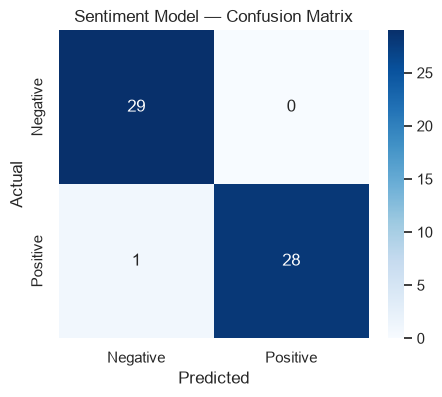

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sentiment_predictions = sentiment_model.predict(X_test_tfidf)

sentiment_accuracy = accuracy_score(
    y_test_sentiment,
    sentiment_predictions
)

print("Accuracy:", round(sentiment_accuracy, 4))
print("\nClassification Report:")
print(classification_report(
    y_test_sentiment,
    sentiment_predictions,
    zero_division=0
))

# Confusion matrix — a quick visual of where the model got confused
cm = confusion_matrix(y_test_sentiment, sentiment_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Model — Confusion Matrix")
plt.show()

## Step 1.7: Turn the Model into a Reusable Function

Right now, our model can only make a prediction if we manually repeat several lines of code. To make it genuinely usable, we wrap the entire process into one Python function, `predict_sentiment()`, that anyone can call with a single sentence.

What the function does, step by step:
1. Takes a new, unseen sentence as input.
2. Transforms it into numbers using the **same** TF-IDF vectorizer trained earlier — never a new one, since the vocabulary must match what the model was actually trained on.
3. Passes those numbers to the trained model to get a prediction (0 or 1).
4. Retrieves the model's confidence — how sure it is about that prediction, expressed as a probability.
5. Converts the numeric prediction into a readable label ("Positive 😊" or "Negative 😞") and returns it together with the confidence score.

We then test this function on three brand-new sentences that were never part of the original dataset, to see how well it generalizes.

In [8]:
def predict_sentiment(review):
    review_vector = vectorizer.transform([review])
    prediction = sentiment_model.predict(review_vector)[0]
    probability = sentiment_model.predict_proba(review_vector)[0].max()

    result = "Positive 😊" if prediction == 1 else "Negative 😞"
    return result, probability

test_reviews = [
    "The movie was absolutely fantastic",
    "This was boring and disappointing",
    "I loved the acting and the story"
]

for review in test_reviews:
    result, confidence = predict_sentiment(review)
    print("Review:", review)
    print("Prediction:", result)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("-" * 60)

Review: The movie was absolutely fantastic
Prediction: Positive 😊
Confidence: 64.91 %
------------------------------------------------------------
Review: This was boring and disappointing
Prediction: Negative 😞
Confidence: 73.94 %
------------------------------------------------------------
Review: I loved the acting and the story
Prediction: Positive 😊
Confidence: 69.79 %
------------------------------------------------------------
